In [ ]:
# Import required modules to use for the lab
import pandas as pd
import matplotlib.pyplot as plt

# Uploading dataset
from google.colab import files
uploaded = files.upload()

# Creating dataframe
data = pd.read_csv("suicide_rates.csv")
print(data.head())

# Importing necessary modules
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm


   country  year     sex          age  suicides_no  population  \
0  Albania  1987    male  15-24 years           21      312900   
1  Albania  1987    male  35-54 years           16      308000   
2  Albania  1987  female  15-24 years           14      289700   
3  Albania  1987    male    75+ years            1       21800   
4  Albania  1987    male  25-34 years            9      274300   

   suicides/100k pop country-year  HDI for year  gdp_for_year ($)   \
0               6.71  Albania1987           NaN      2,156,624,900   
1               5.19  Albania1987           NaN      2,156,624,900   
2               4.83  Albania1987           NaN      2,156,624,900   
3               4.59  Albania1987           NaN      2,156,624,900   
4               3.28  Albania1987           NaN      2,156,624,900   

   gdp_per_capita ($)       generation  
0                 796     Generation X  
1                 796           Silent  
2                 796     Generation X  
3                 

<ipython-input-5-fba8bd81d257>:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap('tab20', len(countries))  # Use a colormap (20 unique colors in 'tab20')


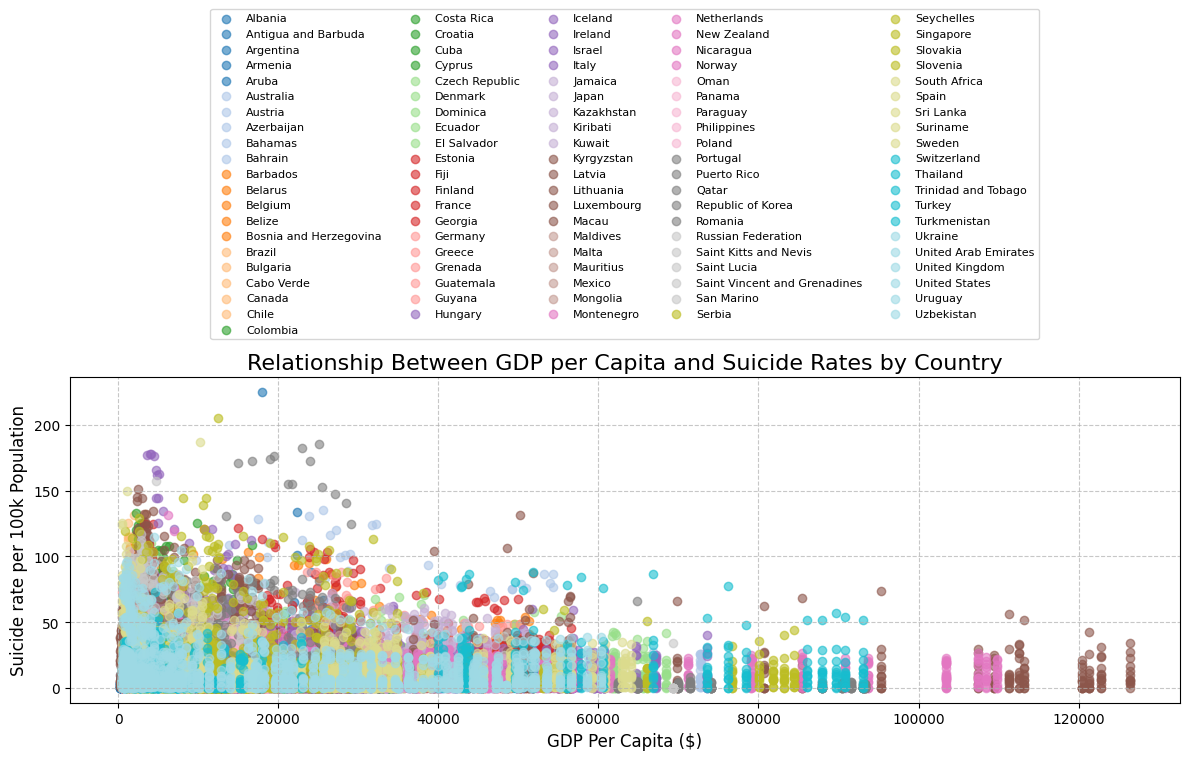

In [ ]:
# Drop rows with missing values and ensure if the data is numeric or integer
data['gdp_per_capita ($)'] = pd.to_numeric(data['gdp_per_capita ($)'], errors='coerce')
data['suicides/100k pop'] = pd.to_numeric(data['suicides/100k pop'], errors='coerce')
filtered_data = data.dropna(subset=['gdp_per_capita ($)', 'suicides/100k pop'])

# Create a figure for the plots
plt.figure(figsize=(12, 8))

countries = filtered_data['country'].unique()
colors = cm.get_cmap('tab20', len(countries))

# For loop for each country
for i, country in enumerate(countries):
    country_data = filtered_data[filtered_data['country'] == country]

    # Plotting each country data points and its color
    plt.scatter(country_data['gdp_per_capita ($)'], country_data['suicides/100k pop'],
                label=f'{country}', color=colors(i), alpha=0.6)

# Customize the scatterplot
plt.title('Relationship Between GDP per Capita and Suicide Rates by Country', fontsize=16)
plt.xlabel('GDP Per Capita ($)', fontsize=12)
plt.ylabel('Suicide rate per 100k Population', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='lower center', bbox_to_anchor=(0.5, 1.1), ncol=5, fontsize=8)
plt.tight_layout()

# Show the plot
plt.show()







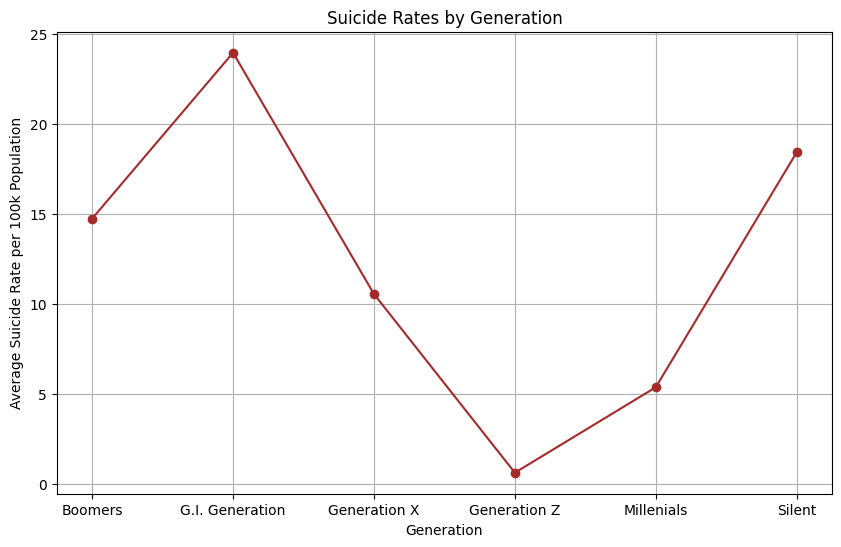

In [ ]:
# Group by generation and calculate the average suicide rate
generation_data = data.groupby('generation')['suicides/100k pop'].mean()

# Customize line chart
plt.figure(figsize=(10, 6))
plt.plot(generation_data.index, generation_data.values, marker='o', linestyle='-', color='brown')
plt.title('Suicide Rates by Generation')
plt.xlabel('Generation')
plt.ylabel('Average Suicide Rate per 100k people')
plt.grid(True)

#Show the chart
plt.show()



<Figure size 1200x800 with 0 Axes>

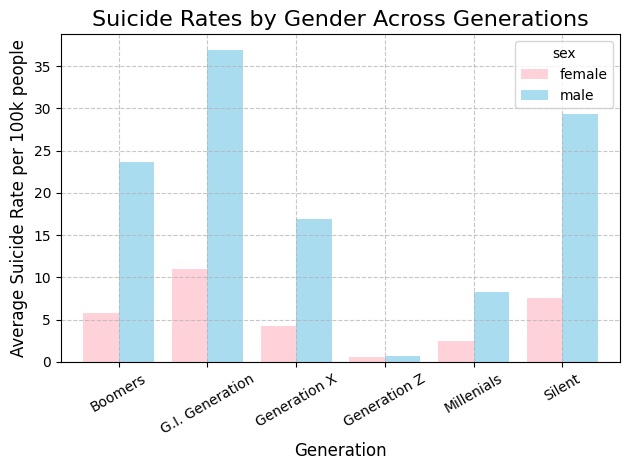

In [ ]:
# Drop rows with missing values and ensure if the data is numeric or integer
data['suicides/100k pop'] = pd.to_numeric(data['suicides/100k pop'], errors='coerce')
filtered_data = data.dropna(subset=['suicides/100k pop', 'generation', 'sex'])

# Group by generation and gender and calculate the mean suicide rate per 100k people
gender_generation_data = filtered_data.groupby(['generation', 'sex'])['suicides/100k pop'].mean().unstack()

# Plotting the data
plt.figure(figsize=(12, 8))

# Plotting grouped bar chart for suicide rates by gender and generation
gender_generation_data.plot(kind='bar', width=0.8, color=['pink', 'skyblue'], alpha=0.7)

# Customize the bar chart
plt.title('Suicide Rates by Gender Across Generations', fontsize=16)
plt.xlabel('Generation', fontsize=12)
plt.ylabel('Average Suicide Rate per 100k people', fontsize=12)
plt.xticks(rotation=30)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Show the bar chart
plt.show()


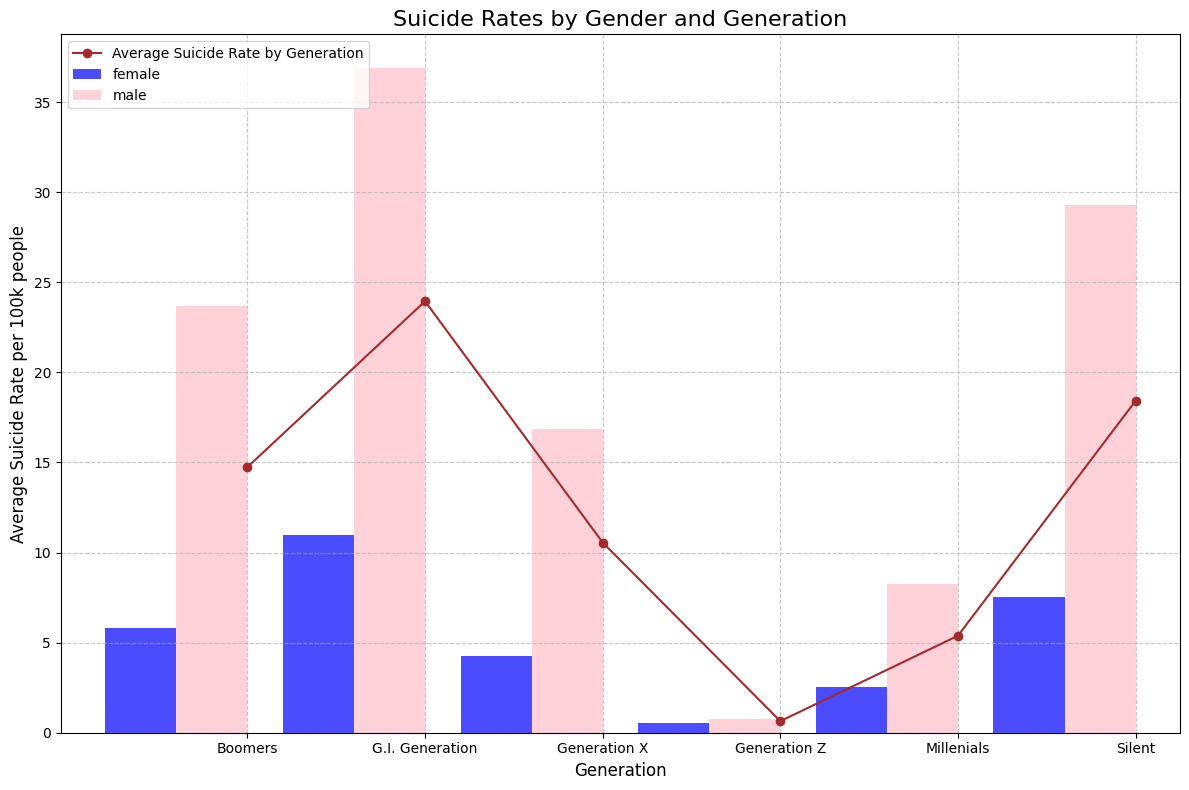

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming the dataset is already loaded
# Ensure relevant columns are numeric
data['suicides/100k pop'] = pd.to_numeric(data['suicides/100k pop'], errors='coerce')

# Drop rows with missing values
filtered_data = data.dropna(subset=['suicides/100k pop', 'generation', 'sex'])

# Group by generation and calculate the average suicide rate
generation_data = data.groupby('generation')['suicides/100k pop'].mean()

# Group by generation and gender, and calculate the mean suicide rate per 100k people
gender_generation_data = filtered_data.groupby(['generation', 'sex'])['suicides/100k pop'].mean().unstack()

# Create a figure
plt.figure(figsize=(12, 8))

# Plot the line chart for suicide rates by generation
plt.plot(generation_data.index, generation_data.values, marker='o', linestyle='-', color='brown', label='Average Suicide Rate by Generation')

# Plot the grouped bar chart for suicide rates by gender and generation
gender_generation_data.plot(kind='bar', width=0.8, color=['blue', 'pink'], alpha=0.7, position=1, ax=plt.gca())

# Adding titles and labels
plt.title('Suicide Rates by Gender and Generation', fontsize=16)
plt.xlabel('Generation', fontsize=12)
plt.ylabel('Average Suicide Rate per 100k people', fontsize=12)
plt.xticks(rotation=0)
plt.grid(True, linestyle='--', alpha=0.7)

# Add a legend to distinguish the plots
plt.legend(loc='upper left', fontsize=10)

# Show the plot
plt.tight_layout()
plt.show()
